<a href="https://colab.research.google.com/github/Sanataniitb/autoimmune-disease/blob/main/notebooks/original/Arthritis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_excel("/content/drive/MyDrive/Seminar_Sanatan/MTP/ML Codes/Rheumatoid Arthritis ML Input 56 features 106 samples.xlsx")

In [ ]:
data.shape

(56, 107)

In [ ]:
data.head()

,Gene,C1-80-BL,C1-76-BL,C1-119-BL,C1-52-BL,C1-99-BL,C1-88-BL,C1-56-BL,C1-2-BL,C1-42-BL,...,healthy_34,healthy_35,healthy_36,healthy_37,healthy_38,healthy_39,healthy_40,healthy_41,healthy_42,healthy_43
0,CD40,168,306,36,99,138,202,148,136,363,...,679,230,854,383,243,545,1212,263,1641,272
1,CORO7-PAM16,5368,6911,3522,4774,3661,4129,3387,2466,5187,...,1,0,0,0,0,0,1,0,0,0
2,PTGES3L-AARSD1,295,564,129,194,221,284,173,165,328,...,0,0,0,0,0,0,0,0,0,0
3,IL23A,41,42,7,0,25,103,69,36,56,...,242,70,275,174,183,112,281,118,175,153
4,CCR6,95,327,116,313,117,134,219,205,741,...,48,15,37,42,34,46,95,41,32,26


In [ ]:
cols=list(data.Gene)
#cols=list(data['Unnamed: 0'])

In [ ]:
data=data.T

In [ ]:
data.columns=cols

In [ ]:
data["target"]=data.index

In [ ]:
data.reset_index(inplace=True)

In [ ]:
data.head()

,index,CD40,CORO7-PAM16,PTGES3L-AARSD1,IL23A,CCR6,TNFAIP3,RPN2,TGIF2,CRHR1,...,ST20-MTHFS,PMF1-BGLAP,ISY1-RAB43,MYZAP,COMMD3-BMI1,RPS10-NUDT3,SRXN1,KMT2B,RBAK-RBAKDN,target
0,Gene,CD40,CORO7-PAM16,PTGES3L-AARSD1,IL23A,CCR6,TNFAIP3,RPN2,TGIF2,CRHR1,...,ST20-MTHFS,PMF1-BGLAP,ISY1-RAB43,MYZAP,COMMD3-BMI1,RPS10-NUDT3,SRXN1,KMT2B,RBAK-RBAKDN,Gene
1,C1-80-BL,168,5368,295,41,95,358,3925,616,0,...,360,535,504,27,374,2436,927,2273,0,C1-80-BL
2,C1-76-BL,306,6911,564,42,327,983,4628,540,0,...,712,669,1434,151,579,2580,2072,3950,3,C1-76-BL
3,C1-119-BL,36,3522,129,7,116,509,3183,317,31,...,345,184,479,73,350,919,1181,1730,5,C1-119-BL
4,C1-52-BL,99,4774,194,0,313,1097,5124,381,29,...,233,222,625,93,646,1259,1615,2736,0,C1-52-BL


In [ ]:
data.drop(index=data.index[0],axis=0,inplace=True)

In [ ]:
def val(row):
    if row[0]=="C":
        return 1
    else:
        return 0

In [ ]:
data["target"]=data.target.apply(val)

In [ ]:
list(data.target).count(1)

63

In [ ]:
data.head()

,index,CD40,CORO7-PAM16,PTGES3L-AARSD1,IL23A,CCR6,TNFAIP3,RPN2,TGIF2,CRHR1,...,ST20-MTHFS,PMF1-BGLAP,ISY1-RAB43,MYZAP,COMMD3-BMI1,RPS10-NUDT3,SRXN1,KMT2B,RBAK-RBAKDN,target
1,C1-80-BL,168,5368,295,41,95,358,3925,616,0,...,360,535,504,27,374,2436,927,2273,0,1
2,C1-76-BL,306,6911,564,42,327,983,4628,540,0,...,712,669,1434,151,579,2580,2072,3950,3,1
3,C1-119-BL,36,3522,129,7,116,509,3183,317,31,...,345,184,479,73,350,919,1181,1730,5,1
4,C1-52-BL,99,4774,194,0,313,1097,5124,381,29,...,233,222,625,93,646,1259,1615,2736,0,1
5,C1-99-BL,138,3661,221,25,117,263,2307,371,4,...,249,340,453,14,389,2071,905,1403,0,1


In [ ]:
data.drop("index",axis=1,inplace=True)

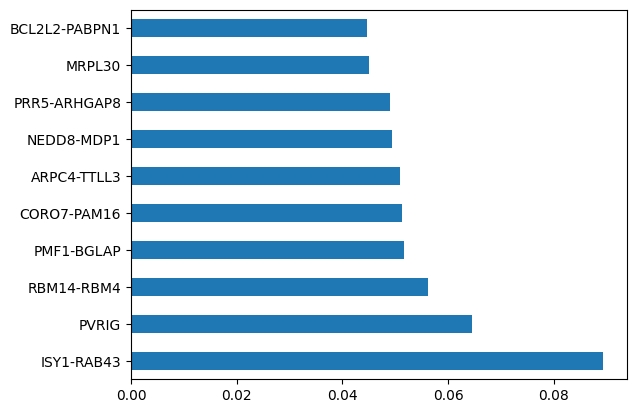

In [ ]:
import numpy as np

X = data.iloc[:,0:-1]  #independent columns
y = data.iloc[:,-1]    #target column i.e price range
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model = ExtraTreesClassifier()
model.fit(X,y)
#print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
important_feature=list(feat_importances[feat_importances>0.01].index)

In [ ]:
len(important_feature)

27

In [ ]:
important_feature

['CORO7-PAM16',
 'PTGES3L-AARSD1',
 'CRHR1',
 'TRAPPC5',
 'MRPL30',
 'HLA-G',
 'PVRIG',
 'AS3MT',
 'TRIM39-RPP21',
 'PRR5-ARHGAP8',
 'RBM14-RBM4',
 'ARPC4-TTLL3',
 'TMED7-TICAM2',
 'EEF1G',
 'NEDD8-MDP1',
 'SMIM3',
 'BCL2L2-PABPN1',
 'TVP23C-CDRT4',
 'ST20-MTHFS',
 'PMF1-BGLAP',
 'ISY1-RAB43',
 'MYZAP',
 'COMMD3-BMI1',
 'RPS10-NUDT3',
 'SRXN1',
 'KMT2B',
 'RBAK-RBAKDN']

In [ ]:
x=data.drop("target",axis=1)

In [ ]:
x=x[important_feature]

In [ ]:
x.head()

,CORO7-PAM16,PTGES3L-AARSD1,CRHR1,TRAPPC5,MRPL30,HLA-G,PVRIG,AS3MT,TRIM39-RPP21,PRR5-ARHGAP8,...,TVP23C-CDRT4,ST20-MTHFS,PMF1-BGLAP,ISY1-RAB43,MYZAP,COMMD3-BMI1,RPS10-NUDT3,SRXN1,KMT2B,RBAK-RBAKDN
1,5368,295,0,596,170,651,506,161,479,38,...,141,360,535,504,27,374,2436,927,2273,0
2,6911,564,0,478,320,1613,426,60,589,105,...,147,712,669,1434,151,579,2580,2072,3950,3
3,3522,129,31,273,155,766,243,68,268,65,...,94,345,184,479,73,350,919,1181,1730,5
4,4774,194,29,388,251,828,300,72,307,104,...,260,233,222,625,93,646,1259,1615,2736,0
5,3661,221,4,389,161,416,571,12,282,76,...,124,249,340,453,14,389,2071,905,1403,0


In [ ]:
import numpy as np

def standardize_features_by_class(X, y):
    classes = np.unique(y)
    standardized_features = []

    for cls in classes:
        class_features = X[y == cls]
        class_means = np.mean(class_features, axis=0)
        class_stds = np.std(class_features, axis=0)
        standardized_class_features = (class_features - class_means) / (class_stds+1)
        standardized_features.append(standardized_class_features)
    standardized_X = np.concatenate(standardized_features)

    return standardized_X

standardized_X = standardize_features_by_class(x, y)

In [ ]:
x.head()

,CORO7-PAM16,PTGES3L-AARSD1,CRHR1,TRAPPC5,MRPL30,HLA-G,PVRIG,AS3MT,TRIM39-RPP21,PRR5-ARHGAP8,...,TVP23C-CDRT4,ST20-MTHFS,PMF1-BGLAP,ISY1-RAB43,MYZAP,COMMD3-BMI1,RPS10-NUDT3,SRXN1,KMT2B,RBAK-RBAKDN
1,5368,295,0,596,170,651,506,161,479,38,...,141,360,535,504,27,374,2436,927,2273,0
2,6911,564,0,478,320,1613,426,60,589,105,...,147,712,669,1434,151,579,2580,2072,3950,3
3,3522,129,31,273,155,766,243,68,268,65,...,94,345,184,479,73,350,919,1181,1730,5
4,4774,194,29,388,251,828,300,72,307,104,...,260,233,222,625,93,646,1259,1615,2736,0
5,3661,221,4,389,161,416,571,12,282,76,...,124,249,340,453,14,389,2071,905,1403,0


In [ ]:
y=data["target"]

In [ ]:
y.head()

1    1
2    1
3    1
4    1
5    1
Name: target, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( standardized_X, y, test_size=0.23, random_state=42)

In [ ]:
list(y_test).count(1)

15

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import svm

In [ ]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
y_tpred = classifier.predict(X_train)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[ 4  6]
 [ 5 10]]


Text(50.722222222222214, 0.5, 'actual')

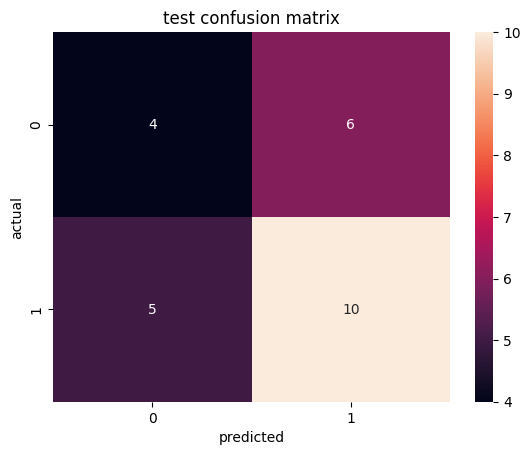

In [ ]:
import seaborn as sn
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
from sklearn.metrics import accuracy_score
print ("Accuracy train : ", accuracy_score(y_train, y_tpred))
print ("Accuracy test: ", accuracy_score(y_test, y_pred))

Accuracy train :  0.8641975308641975
Accuracy test:  0.56


In [ ]:
from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

f1_score train :  0.855380620029216
f1_score test:  0.533106960950764


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, y_pred))
print('Recall: %.3f' % recall_score(y_test, y_pred))

Precision: 0.625
Recall: 0.667


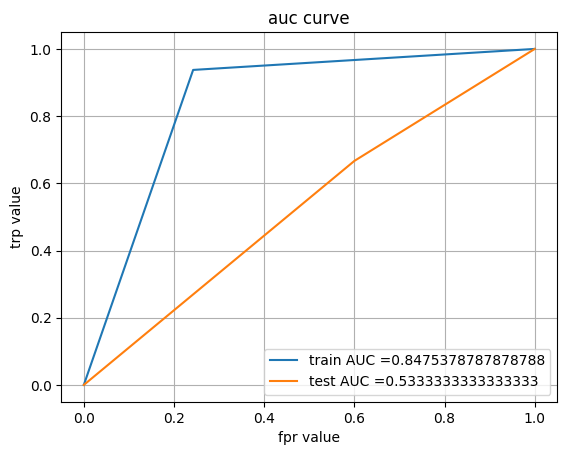

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

0.5925925925925926
0.6
Confusion Matrix : 
 [[ 0 10]
 [ 0 15]]
F1 score train :  0.37209302325581395
F1 score test:  0.37499999999999994


Text(50.722222222222214, 0.5, 'actual')

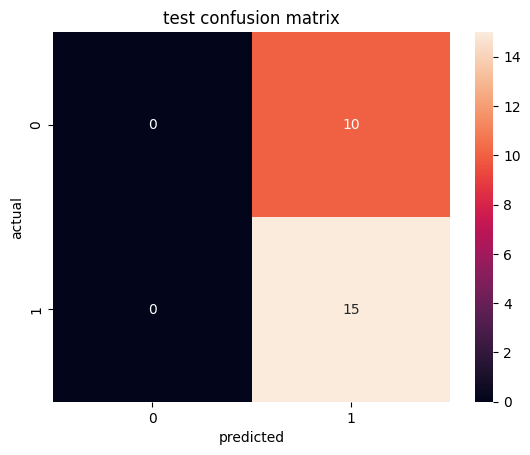

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

svc_model = SVC(C=0.5, kernel='rbf', gamma=1)
svc_model.fit(X_train, y_train)
prediction_t = svc_model .predict(X_train)
prediction = svc_model .predict(X_test)
# check the accuracy on the training set
print(svc_model.score(X_train, y_train))
print(svc_model.score(X_test, y_test))
cm = confusion_matrix(y_test, prediction)
print ("Confusion Matrix : \n", cm)
from sklearn.metrics import f1_score
print ("F1 score train : ", f1_score(y_train, prediction_t,average="macro"))
print ("F1 score test: ", f1_score(y_test, prediction,average="macro"))
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test,prediction))
print('Recall: %.3f' % recall_score(y_test,prediction))

Precision: 0.600
Recall: 1.000


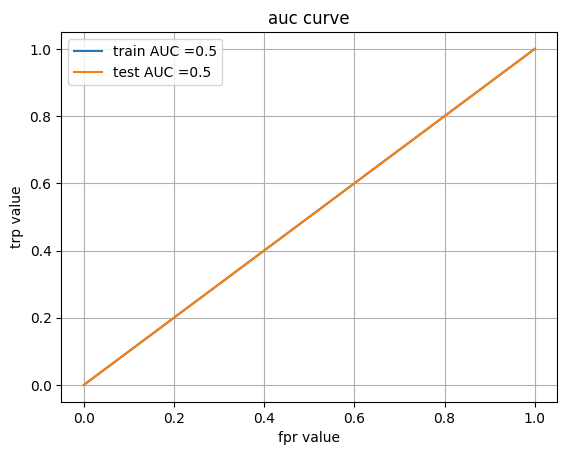

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, prediction_t)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, prediction)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
gbdt=XGBClassifier()
parameters ={"max_depth":[3,4,5,6,7],"n_estimators":[10,50,100,150,200]}
clf1 = GridSearchCV(gbdt, parameters, cv=4,n_jobs=-1,scoring='f1_macro',return_train_score=True)
clf1.fit(X_train, y_train)
clf1.best_estimator_.get_params()

{'objective': 'binary:logistic',
 'use_label_encoder': None,
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'gpu_id': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'n_estimators': 10,
 'n_jobs': None,
 'num_parallel_tree': None,
 'predictor': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

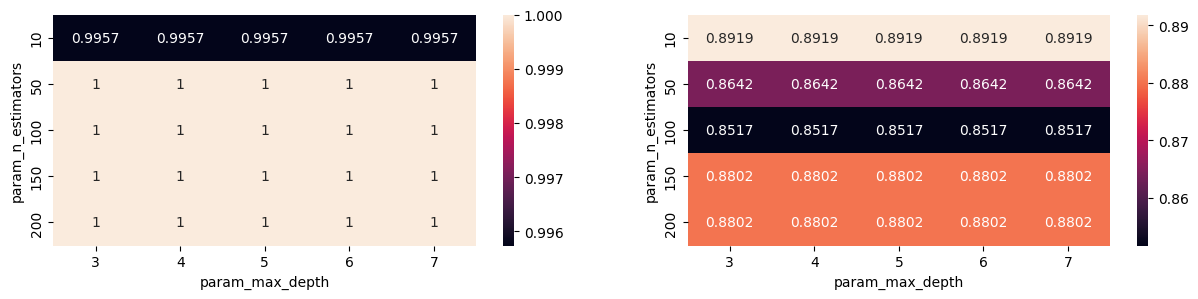

In [ ]:
import pandas as pd
import seaborn as sn
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
result=pd.DataFrame.from_dict(clf1.cv_results_)
max_score=result.groupby(["param_n_estimators","param_max_depth"]).max()
max_score=max_score.unstack()[["mean_test_score","mean_train_score"]]
a=sn.heatmap(max_score.mean_train_score,annot=True,fmt=".4g")
b=fig.add_subplot(122)
a=sn.heatmap(max_score.mean_test_score,annot=True,fmt=".4g")

In [ ]:
def batch_predict(clf, data):
    # roc_auc_score(y_true, y_score) the 2nd parameter should be probability estimates of the positive class
    # not the predicted outputs

    y_data_pred = []
    tr_loop = data.shape[0] - data.shape[0]%1000
    for i in range(0, tr_loop, 1000):
        y_data_pred.extend(clf.predict_proba(data[i:i+1000])[:,1])
    # we will be predicting for the last data points
    if data.shape[0]%1000 !=0:
        y_data_pred.extend(clf.predict_proba(data[tr_loop:])[:,1])

    return y_data_pred

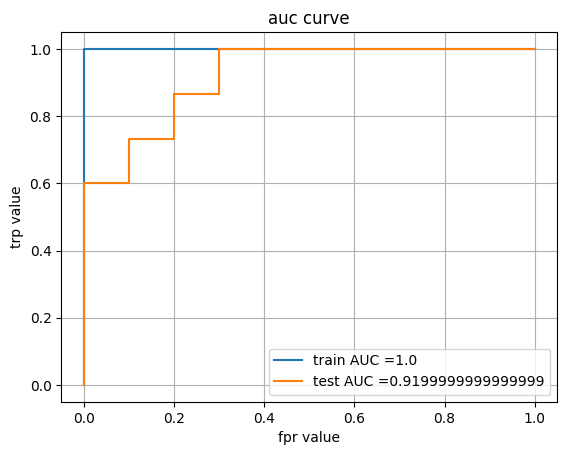

In [ ]:
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
gbdt1 = XGBClassifier(max_depth=4,n_estimators=100)
gbdt1.fit(X_train, y_train)

y_train_pred1 = batch_predict(gbdt1, X_train)
y_test_pred1= batch_predict(gbdt1, X_test)

train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_train_pred1)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_test_pred1)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
def find_best_threshold(threshould, fpr, tpr):
    t = threshould[np.argmax(tpr*(1-fpr))]
    # (tpr*(1-fpr)) will be maximum if your fpr is very low and tpr is very high
    #print("the maximum value of tpr*(1-fpr)", max(tpr*(1-fpr)), "for threshold", np.round(t,3))
    return t

def predict_with_best_t(proba, threshould):
    predictions = []
    for i in proba:
        if i>=threshould:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

Text(792.3131313131312, 0.5, 'actual')

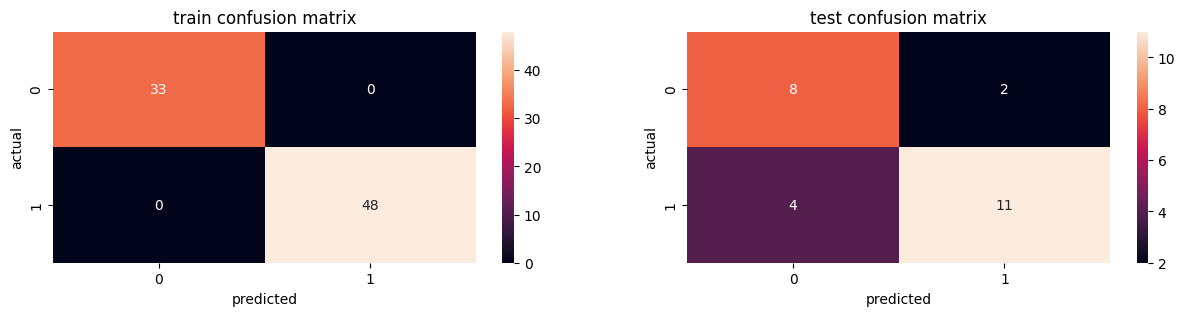

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
best_t = find_best_threshold(tr_thresholds, train_fpr, train_tpr)
k=confusion_matrix(y_train, predict_with_best_t(y_train_pred1, best_t))
fig=plt.figure(figsize=(15,3))
a=fig.add_subplot(121)
a=sn.heatmap(k,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
a.set_title("train confusion matrix")
a.set_xlabel("predicted")
a.set_ylabel("actual")
b=fig.add_subplot(122)
y_pred=predict_with_best_t(y_test_pred1, best_t)
c_test=confusion_matrix(y_test, y_pred)
b=sn.heatmap(c_test,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
print(accuracy_score(y_train, predict_with_best_t(y_train_pred1, best_t)))
print(accuracy_score(y_test, predict_with_best_t(y_test_pred1, best_t)))

from sklearn.metrics import f1_score
print ("f1_score train : ", f1_score(y_train, y_tpred,average="macro"))
print ("f1_score test: ", f1_score(y_test, y_pred,average="macro"))

1.0
0.76
f1_score train :  0.855380620029216
f1_score test:  0.7564935064935063


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, y_pred))
print('Recall: %.3f' % recall_score(y_test, y_pred))

Precision: 0.846
Recall: 0.733


In [ ]:
a=X_test[3:4]

In [ ]:
if gbdt1.predict(a)[0]==1:
  print("disease")
else:
  print("healthy")

healthy


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dense, Dropout
from keras.regularizers import l2
from keras.optimizers import Adam
input_dim = x.shape[1]
model = Sequential()
model.add(Dense(256, activation='relu', input_dim=input_dim))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split
x = np.asarray(standardized_X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.23, random_state=42)
import numpy as np

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1,validation_data=(X_test, y_test))

# # Evaluate the model
# loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
# print('Test loss:', loss)
# print('Test accuracy:', accuracy)

In [ ]:
from keras.callbacks import TensorBoard

# Create a TensorBoard callback
tensorboard_callback = TensorBoard(log_dir='', histogram_freq=1)

# Train the model
history = model.fit(X_train, y_train, epochs=12, batch_size=16, verbose=1,
                    validation_data=(X_test, y_test), callbacks=[tensorboard_callback])

Epoch 1/12
6/6 [==============================] - 8s 84ms/step - loss: 0.9756 - accuracy: 0.5556 - val_loss: 0.9653 - val_accuracy: 0.7600
Epoch 2/12
6/6 [==============================] - 0s 26ms/step - loss: 0.9601 - accuracy: 0.6667 - val_loss: 0.9349 - val_accuracy: 0.8400
Epoch 3/12
6/6 [==============================] - 0s 32ms/step - loss: 0.8892 - accuracy: 0.8148 - val_loss: 0.8954 - val_accuracy: 0.8400
Epoch 4/12
6/6 [==============================] - 0s 34ms/step - loss: 0.8591 - accuracy: 0.8272 - val_loss: 0.8441 - val_accuracy: 0.8400
Epoch 5/12
6/6 [==============================] - 0s 29ms/step - loss: 0.8141 - accuracy: 0.8148 - val_loss: 0.8026 - val_accuracy: 0.8400
Epoch 6/12
6/6 [==============================] - 0s 31ms/step - loss: 0.7381 - accuracy: 0.8642 - val_loss: 0.7941 - val_accuracy: 0.8400
Epoch 7/12
6/6 [==============================] - 0s 32ms/step - loss: 0.6745 - accuracy: 0.8889 - val_loss: 0.7360 - val_accuracy: 0.8400
Epoch 8/12
6/6 [===========

In [ ]:

%load_ext tensorboard
%tensorboard --logdir logs

In [ ]:
model.evaluate(X_test, y_test)

1/1 [==============================] - 0s 25ms/step - loss: 0.5950 - accuracy: 0.9200


[0.5950087308883667, 0.9200000166893005]

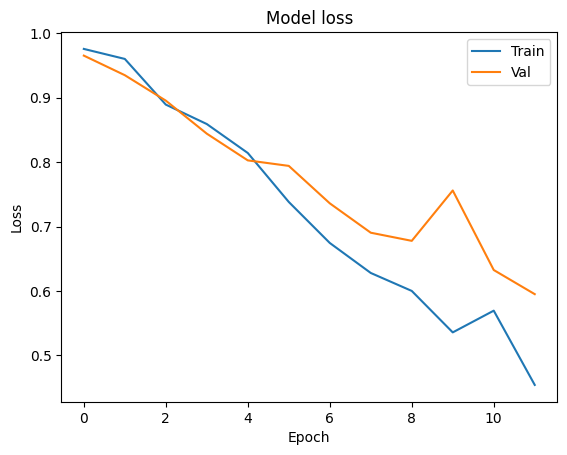

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

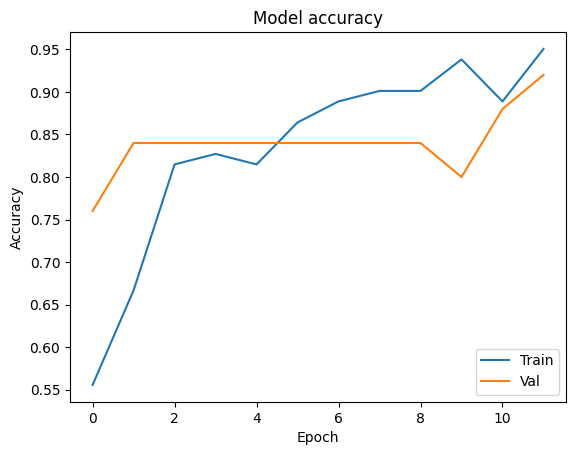

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [ ]:
 y_tpred=model.predict(X_train)
y_pred=model.predict(X_test)

1/1 [==============================] - 0s 17ms/step


In [ ]:
def predict_with_best_t(proba):
    predictions = []
    for i in proba:
        if i>=0.5:
            predictions.append(1)
        else:
            predictions.append(0)
    return predictions

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predict_with_best_t(y_pred))
print ("Confusion Matrix : \n", cm)

Confusion Matrix : 
 [[10  0]
 [ 2 13]]


Text(50.722222222222214, 0.5, 'actual')

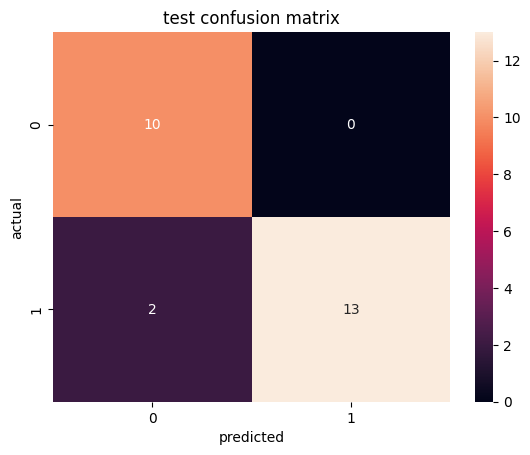

In [ ]:
b=sn.heatmap(cm,annot=True,yticklabels=[0,1],xticklabels=[0,1],fmt="g")
b.set_title("test confusion matrix")
b.set_xlabel("predicted")
b.set_ylabel("actual")

In [ ]:
from sklearn.metrics import f1_score
print ("f1_score test: ", f1_score(y_test, predict_with_best_t(y_pred),average="macro"))

f1_score test:  0.9188311688311688


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, predict_with_best_t(y_pred)))
print('Recall: %.3f' % recall_score(y_test, predict_with_best_t(y_pred)))

Precision: 1.000
Recall: 0.867


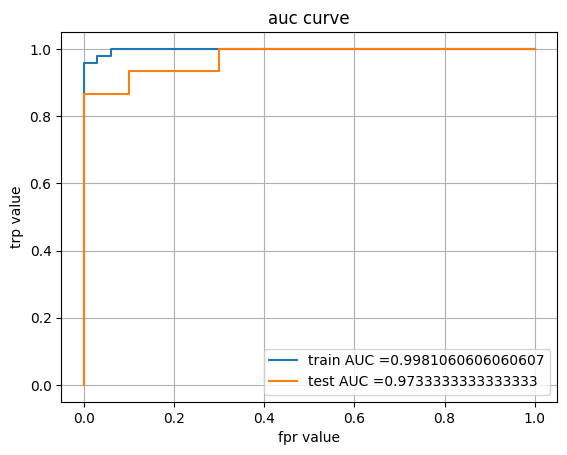

In [ ]:
from sklearn.metrics import roc_curve, auc
train_fpr, train_tpr, tr_thresholds = roc_curve(y_train, y_tpred)
test_fpr, test_tpr, te_thresholds = roc_curve(y_test, y_pred)

plt.plot(train_fpr, train_tpr, label="train AUC ="+str(auc(train_fpr, train_tpr)))
plt.plot(test_fpr, test_tpr, label="test AUC ="+str(auc(test_fpr, test_tpr)))
plt.legend()
plt.xlabel("fpr value")
plt.ylabel("trp value")
plt.title("auc curve")
plt.grid()
plt.show()

In [ ]:
if model.predict(X_test[5:6])[0][0]<0.5:
  print("healthy")
else:
  print("disease")

1/1 [==============================] - 0s 17ms/step
healthy


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
print('Precision: %.3f' % precision_score(y_test, predict_with_best_t(y_pred)))
print('Recall: %.3f' % recall_score(y_test, predict_with_best_t(y_pred)))

Precision: 1.000
Recall: 0.867
